# Computer Vision

`torchvision` - główna biblioteka klasyfikacji obrazów w pytorch

`torch` rozpoczyna swoje operacje od momentu kiedy obrazy przetwarzane są w tensory, ale wcześniej odwołuje się też do innych bibliotek takich jak Pillow czy OpenCV

In [1]:
import torch
import torchvision
import torch.nn as nn
import torchvision.transforms as transforms
import pandas as pd
import numpy as np
import torch.nn.functional as F
import random
import matplotlib.pyplot as plt

In [2]:
def set_seed(seed):
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True)

set_seed(SEED)

# os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"  # wymagane przez niektóre operacje CUDA
device = torch.device("cuda")

## Zbiory danych
Razem z torchvision dostępne są standardowo wykorzystywane zbiory danych. Na potrzeby dzisiejszych ćwiczeń skorzystamy ze zbioru CIFAR-10 który ładujemy jako `torchvision.datasets.CIFAR10`.

In [3]:
batch_size = 32
classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

Z pikseli do tensorów:

100%|██████████| 170M/170M [10:01<00:00, 284kB/s]    


first element: (<PIL.Image.Image image mode=RGB size=32x32 at 0x7B8866901630>, 1)


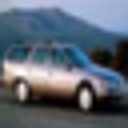

PIL -> Numpy: shape=(32, 32, 3) | dtype=uint8 | min=0 | max=254


In [4]:
trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True)
testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True)

sample = trainset[4]
print("first element:", sample)
sample[0].resize((128,128)).show()
np_sample = np.array(sample[0])
print(f"PIL -> Numpy: shape={np_sample.shape} | dtype={np_sample.dtype} | min={np_sample.min()} | max={np_sample.max()}")


In [5]:
transform = transforms.Compose([transforms.ToTensor()])
trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)

sample = trainset[4]
print(f"PIL -> Tensor: shape={sample[0].shape} | dtype={sample[0].dtype} | min={sample[0].min()} | max={sample[0].max()}")

all_samples = torch.stack([sample[0] for sample in trainset])
print(f"Data norm: mean={all_samples.mean():.4f} | std={all_samples.std():.4f}")
print(f"Data norm per channel: mean={all_samples.mean(axis=(0,2,3))} | std={all_samples.std(axis=(0,2,3))}")


PIL -> Tensor: shape=torch.Size([3, 32, 32]) | dtype=torch.float32 | min=0.0 | max=0.9960784316062927
Data norm: mean=0.4734 | std=0.2516
Data norm per channel: mean=tensor([0.4914, 0.4822, 0.4465]) | std=tensor([0.2470, 0.2435, 0.2616])


In [6]:
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)

all_samples = torch.stack([sample[0] for sample in trainset])
print(f"Data norm: mean={all_samples.mean():.4f} | std={all_samples.std():.4f}")
print(f"Data norm per channel: mean={all_samples.mean(axis=(0,2,3))} | std={all_samples.std(axis=(0,2,3))}")

Data norm: mean=-0.0000 | std=1.0000
Data norm per channel: mean=tensor([-1.2871e-06, -1.7074e-04,  1.1819e-04]) | std=tensor([1.0001, 0.9999, 1.0000])


In [7]:
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                          shuffle=True, num_workers=16)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                         shuffle=False, num_workers=16)

# get some random training images
images, labels = next(iter(trainloader))

In [8]:
import torch
from torch import Tensor

class Normalize(torch.nn.Module):
    def __init__(self, mean: list, std: list) -> None:
        super().__init__()
        self.mean: Tensor = torch.tensor(data=mean).view(-1, 1, 1)
        self.std: Tensor = torch.tensor(data=std).view(-1, 1, 1)

    def __call__(self, image: Tensor) -> Tensor:
        # image shape: [N_channels, H, W] uzyj mean i std
        pass

In [9]:
print(images.shape)
print(torchvision.utils.make_grid(images, nrow=8, padding=0).shape)

torch.Size([32, 3, 32, 32])
torch.Size([3, 128, 256])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9894737..2.1264887].


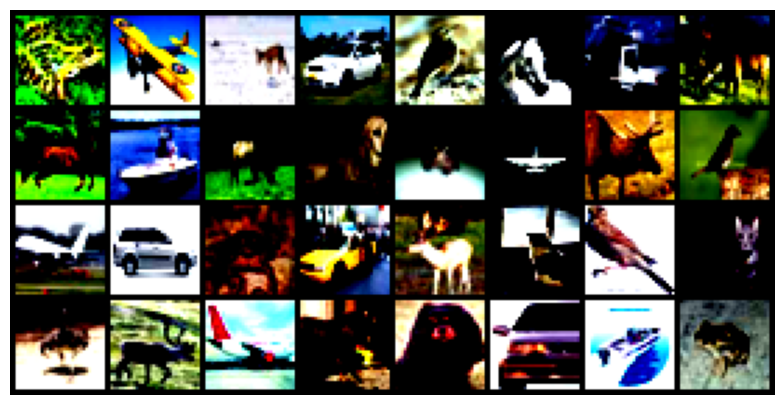

     frog     plane      deer       car      bird     horse     truck      deer
    horse      ship      deer       dog      frog     plane      deer      bird
    plane       car      frog       car      deer       cat      bird       cat
     bird      deer     plane     horse       dog       car      ship      frog


In [10]:
def imshow(img):
    plt.figure(figsize = (10,5))

    # ???
    # potrzeba dodac unnormalize dodajacy std i mean zeby podejrzec rzeczywiste obrazki a nie znormalizowane
    img = img
    # ???

    npimg = img.numpy()
    plt.axis('off')
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

imshow(torchvision.utils.make_grid(images, nrow=8))

for row_idx in range(0, batch_size, 8):
    print(' '.join('%9s' % classes[labels[j]] for j in range(row_idx, row_idx + 8)))

In [11]:
transform_output = transforms.Compose([
    # ??? unnormalize
    transforms.ToPILImage(),
    transforms.Resize((256,256))
])

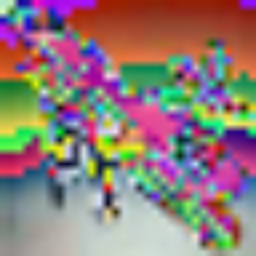

In [12]:
transform_output(images[1])

## Konwolucja

![](https://cs231n.github.io/assets/cnn/depthcol.jpeg)

Kolejność wymiarów:

In [13]:
print('[batch_size, channels, height, width]')
images[0:1].size()

[batch_size, channels, height, width]


torch.Size([1, 3, 32, 32])

conv: 
+ zmienia wymiarowość na height i width
+ zmienia liczbę kanałów

In [15]:
device = 'cpu'
conv1 = nn.Conv2d(in_channels=3, out_channels=6, kernel_size=5).to(device)
conv1(images[0:1].to(device)).size()

torch.Size([1, 6, 28, 28])

+ kernel_size

In [16]:
conv1 = nn.Conv2d(in_channels=3, out_channels=6, kernel_size=(5,2)).to(device)
conv1(images[0:1].to(device)).size()

torch.Size([1, 6, 28, 31])

+ stride

In [17]:
conv1 = nn.Conv2d(in_channels=3, out_channels=6, kernel_size=5, stride=2).to(device)
conv1(images[0:1].to(device)).size()

torch.Size([1, 6, 14, 14])

+ padding

In [18]:
conv1 = nn.Conv2d(in_channels=3, out_channels=6, kernel_size=5, stride=2, padding=1).to(device)
conv1(images[0:1].to(device)).size()

torch.Size([1, 6, 15, 15])

In [40]:
conv1 = nn.Conv2d(in_channels=3, out_channels=2, kernel_size=2, stride=1, padding=[3,3], padding_mode='zeros').to(device)
out = conv1(images[0:1].to(device))
print(out.size())
out

torch.Size([1, 2, 37, 37])


tensor([[[[-0.1537, -0.1537, -0.1537,  ..., -0.1537, -0.1537, -0.1537],
          [-0.1537, -0.1537, -0.1537,  ..., -0.1537, -0.1537, -0.1537],
          [-0.1537, -0.1537, -0.2359,  ..., -0.2668, -0.1537, -0.1537],
          ...,
          [-0.1537, -0.1537, -0.0446,  ..., -0.3389, -0.1537, -0.1537],
          [-0.1537, -0.1537, -0.1537,  ..., -0.1537, -0.1537, -0.1537],
          [-0.1537, -0.1537, -0.1537,  ..., -0.1537, -0.1537, -0.1537]],

         [[-0.0866, -0.0866, -0.0866,  ..., -0.0866, -0.0866, -0.0866],
          [-0.0866, -0.0866, -0.0866,  ..., -0.0866, -0.0866, -0.0866],
          [-0.0866, -0.0866,  0.0944,  ..., -0.6547, -0.0866, -0.0866],
          ...,
          [-0.0866, -0.0866, -0.0370,  ...,  0.0774, -0.0866, -0.0866],
          [-0.0866, -0.0866, -0.0866,  ..., -0.0866, -0.0866, -0.0866],
          [-0.0866, -0.0866, -0.0866,  ..., -0.0866, -0.0866, -0.0866]]]],
       grad_fn=<ConvolutionBackward0>)

In [41]:
for name, param in conv1.named_parameters():
    print(name, param.size())

weight torch.Size([2, 3, 2, 2])
bias torch.Size([2])


$$ \text{output\_size} = \lfloor \frac{\text{input\_size}-\text{kernel\_size}+2\cdot P}{\text{stride}} \rfloor + 1 $$

## Pooling

In [21]:
images[0:1].size()

torch.Size([1, 3, 32, 32])

In [22]:
pool1 = nn.MaxPool2d(kernel_size=2).to(device)
pool1(images[0:1].to(device)).size()

torch.Size([1, 3, 16, 16])

default: stride = kernel_size

In [23]:
pool1 = nn.MaxPool2d(kernel_size=2,stride=2).to(device)
pool1(images[0:1].to(device)).size()

torch.Size([1, 3, 16, 16])

In [25]:
pool1 = nn.MaxPool2d(kernel_size=2,stride=1).to(device)
pool1(images[0:1].to(device)).size()

torch.Size([1, 3, 31, 31])

+ max pooling:

In [26]:
mini_example = images[0:1,0,0:4,0:4]
mini_example

tensor([[[-0.2748, -0.2430, -0.4494, -0.3383],
         [-1.4338, -0.8305, -0.5923, -0.2430],
         [-1.4179, -1.8466, -1.4338,  0.0269],
         [-0.4812, -1.2274, -1.3226,  0.4238]]])

In [27]:
pool1 = nn.MaxPool2d(kernel_size=2).to(device)
pool1(mini_example.to(device))

tensor([[[-0.2430, -0.2430],
         [-0.4812,  0.4238]]])

+ avg pooling

In [28]:
pool1 = nn.AvgPool2d(kernel_size=2).to(device)
pool1(mini_example.to(device))

tensor([[[-0.6955, -0.4058],
         [-1.2433, -0.5764]]])

## Trenowanie sieci konwolucyjnej

In [29]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        ## Warstwa konwolucyjna
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=6, kernel_size=5, stride=1, padding=0)
        ## Warstwa max pooling 
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.pool2 = nn.MaxPool2d(2)
        # !!!
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        # !!!
        x = torch.flatten(x, start_dim=1) # flatten all dimensions except batch
        # print(x.size())
        # !!!
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [30]:
import torch.optim as optim

set_seed(42)

criterion = nn.CrossEntropyLoss()
net = Net().to(device)
optimizer = optim.Adam(net.parameters(), lr=0.001)

net

Net(
  (conv1): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)

In [32]:
for epoch in range(1):  # loop over the dataset multiple times

    running_loss = 0.0
    for data in trainloader:
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)

        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # print statistics
        running_loss += loss.item()

    print('[%d/5] loss: %.3f' %
          (epoch+1 ,  running_loss / 2000))
    running_loss = 0.0

print('Finished Training')

[1/5] loss: 0.980
Finished Training


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9894737..2.0942786].


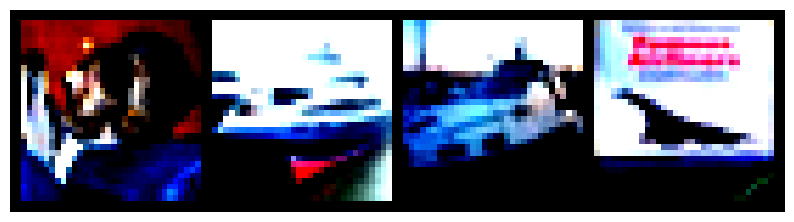

Targets:    cat  ship  ship plane


In [33]:
images, labels = next(iter(testloader))
images = images[:4]

# print images
imshow(torchvision.utils.make_grid(images))
print('Targets: ', ' '.join('%5s' % classes[labels[j]] for j in range(4)))

In [34]:
outputs = net(images.to(device))
outputs

tensor([[-1.8668, -0.2615, -0.4454,  1.4479, -1.4566,  0.4448,  0.0263, -2.1896,
         -0.6397, -0.0698],
        [ 4.4795,  7.1495, -1.9189, -5.4825, -5.8220, -7.9024, -8.0716, -7.3952,
          6.2518,  4.5656],
        [ 2.1225,  3.5450, -0.7197, -2.5181, -2.9420, -3.9088, -4.2707, -3.3443,
          2.7254,  2.6804],
        [ 2.3890,  0.0223,  0.9466, -1.5449, -0.3274, -3.5596, -3.6213, -2.4912,
          2.8929, -0.1564]], grad_fn=<AddmmBackward0>)

In [35]:
_, predicted = torch.max(outputs, 1)

print('Predicted: ', ' '.join('%5s' % classes[predicted[j]]
                              for j in range(4)))

Predicted:    cat   car   car  ship


In [36]:
correct = 0
total = 0
with torch.no_grad():
    for data in testloader:
        images, labels = data
        images = images.to(device)
        outputs = net(images).cpu()

        # the class with the highest energy is what we choose as prediction
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print('Accuracy of the network on the 10000 test images: %d %%' % (
    100 * correct / total))

Accuracy of the network on the 10000 test images: 55 %


In [37]:
correct_pred = {classname: 0 for classname in classes}
total_pred = {classname: 0 for classname in classes}

# again no gradients needed
with torch.no_grad():
    for data in testloader:
        images, labels = data    
        images = images.to(device)
        outputs = net(images).cpu()   
        _, predictions = torch.max(outputs, 1)
        # collect the correct predictions for each class
        for label, prediction in zip(labels, predictions):
            if label == prediction:
                correct_pred[classes[label]] += 1
            total_pred[classes[label]] += 1

  
# print accuracy for each class
for classname, correct_count in correct_pred.items():
    accuracy = 100 * float(correct_count) / total_pred[classname]
    print("Accuracy for class {:5s} is: {:.1f} %".format(classname, 
                                                   accuracy))

Accuracy for class plane is: 57.5 %
Accuracy for class car   is: 66.2 %
Accuracy for class bird  is: 62.0 %
Accuracy for class cat   is: 23.6 %
Accuracy for class deer  is: 34.0 %
Accuracy for class dog   is: 35.7 %
Accuracy for class frog  is: 77.3 %
Accuracy for class horse is: 67.0 %
Accuracy for class ship  is: 62.3 %
Accuracy for class truck is: 73.0 %


#### **Zadanie**: Spróbuj poprawić jakość klasyfikatora zmieniając parametry sieci

## Data augmentation

In [42]:
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))])

batch_size = 4

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                          shuffle=False)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9894737..2.1264887].


<Figure size 1000x700 with 0 Axes>

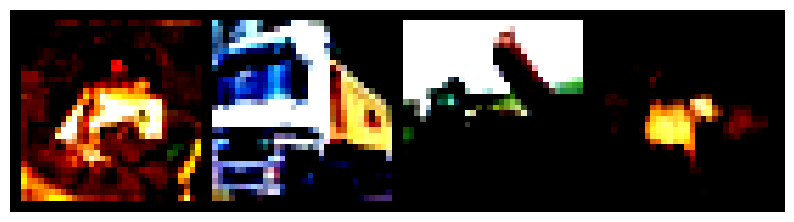

 frog truck truck  deer


In [43]:
plt.figure(figsize = (10,7))
images, labels = next(iter(trainloader))
images = images[:4]
labels = labels[:4]
images_orig = images.clone()

imshow(torchvision.utils.make_grid(images))

print(' '.join('%5s' % classes[labels[j]] for j in range(4)))

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9894737..2.1264887].


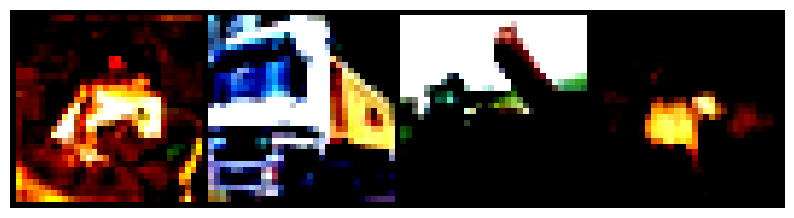

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8624594..2.1264887].


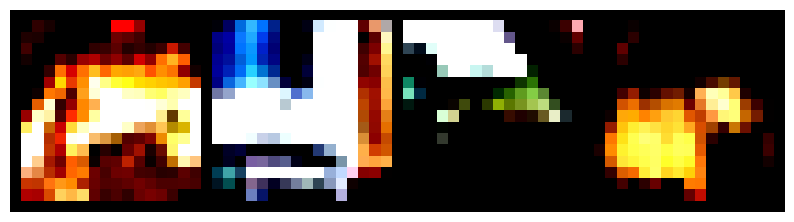

In [44]:
transform = transforms.Compose(
    [transforms.CenterCrop(16),
     transforms.ToTensor(),
     transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                          shuffle=False)
images, labels = next(iter(trainloader))
imshow(torchvision.utils.make_grid(images_orig, padding=1))
imshow(torchvision.utils.make_grid(images, padding=1))

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9894737..2.1264887].


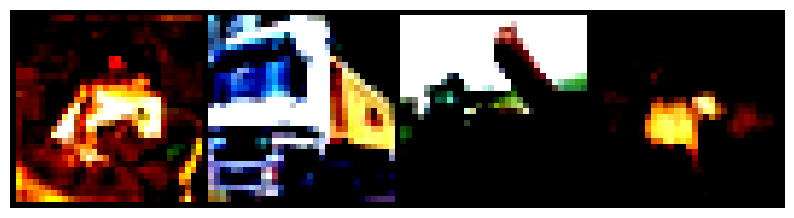

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8624594..2.1264887].


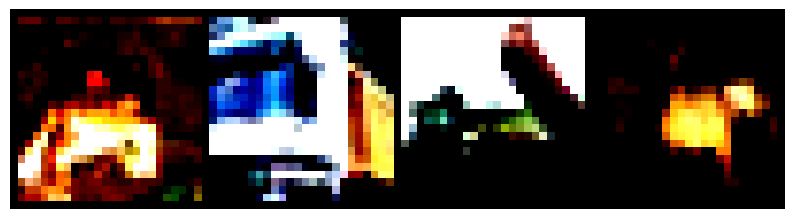

In [45]:
transform = transforms.Compose(
    [transforms.RandomCrop(24),
     transforms.ToTensor(),
     transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                          shuffle=False)
images, labels = next(iter(trainloader))
imshow(torchvision.utils.make_grid(images_orig, padding=1))
imshow(torchvision.utils.make_grid(images, padding=1))

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9894737..2.1264887].


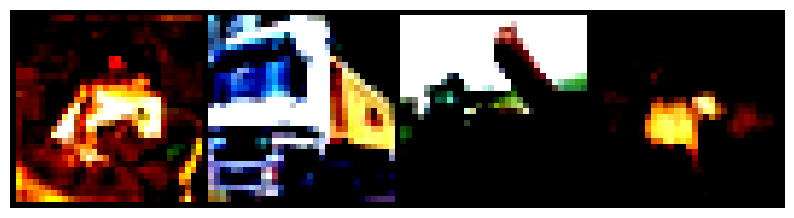

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9894737..2.1264887].


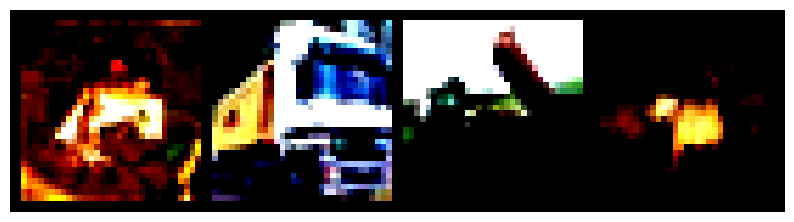

In [46]:
transform = transforms.Compose(
    [transforms.RandomHorizontalFlip(0.5),
     transforms.ToTensor(),
     transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                          shuffle=False)
images, labels = next(iter(trainloader))
imshow(torchvision.utils.make_grid(images_orig, padding=1))
imshow(torchvision.utils.make_grid(images))

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9894737..2.1264887].


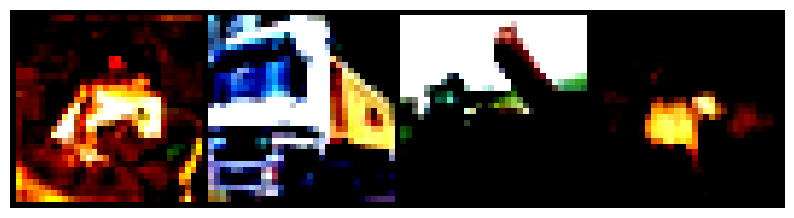

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9894737..2.1264887].


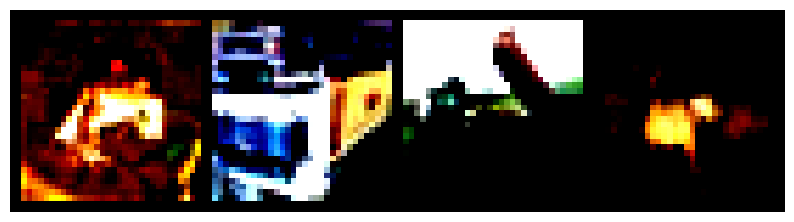

In [47]:
transform = transforms.Compose(
    [transforms.RandomVerticalFlip(0.5),
     transforms.ToTensor(),
     transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                          shuffle=False)
images, labels = next(iter(trainloader))
imshow(torchvision.utils.make_grid(images_orig, padding=1))
imshow(torchvision.utils.make_grid(images))

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9894737..2.1264887].


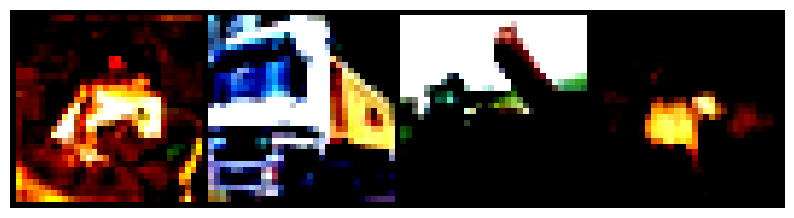

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9894737..2.1264887].


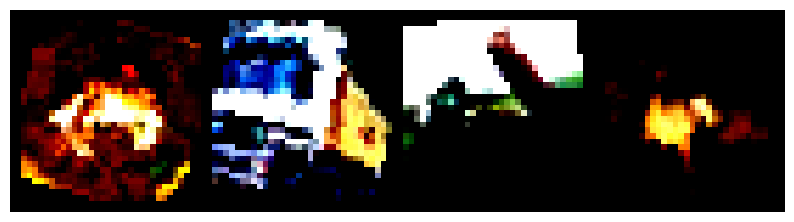

In [48]:
transform = transforms.Compose(
    [transforms.RandomRotation(24),
     transforms.ToTensor(),
     transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                          shuffle=False)
images, labels = next(iter(trainloader))
imshow(torchvision.utils.make_grid(images_orig, padding=1))
imshow(torchvision.utils.make_grid(images))

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9894737..2.1264887].


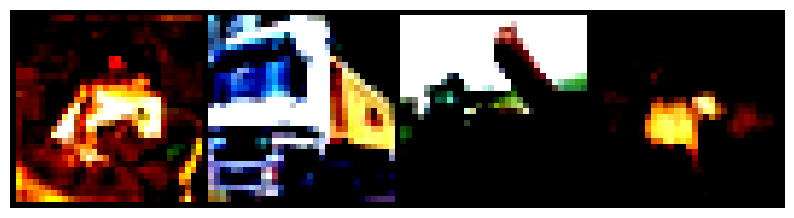

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9894737..2.1264887].


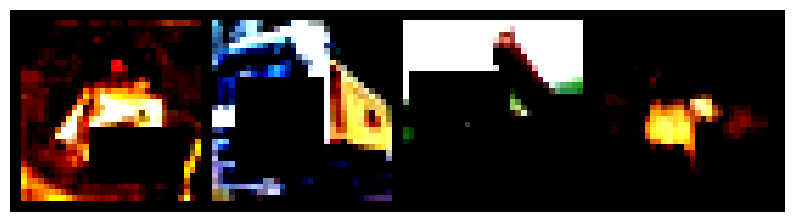

In [49]:
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.RandomErasing(0.6),
     transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                          shuffle=False)
images, labels = next(iter(trainloader))
imshow(torchvision.utils.make_grid(images_orig, padding=1))
imshow(torchvision.utils.make_grid(images))

połączenie w całość:

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9894737..2.1264887].


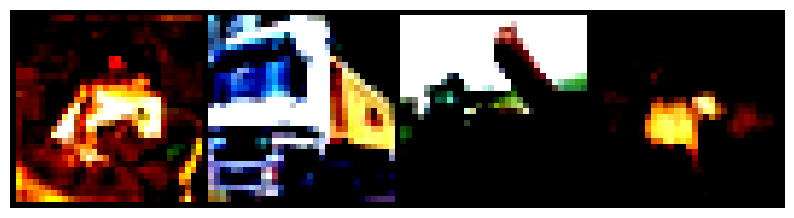

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9894737..2.1264887].


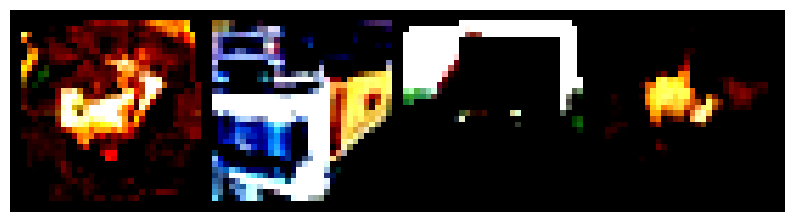

In [51]:
transform = transforms.Compose(
    [transforms.RandomHorizontalFlip(0.5),
     transforms.RandomVerticalFlip(0.5),
     transforms.RandomRotation(24),
     transforms.ToTensor(),
     transforms.RandomErasing(0.4),
     transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                          shuffle=False)
images, labels = next(iter(trainloader))
imshow(torchvision.utils.make_grid(images_orig, padding=1))
imshow(torchvision.utils.make_grid(images))

In [52]:
transform = transforms.Compose(
    [transforms.RandomHorizontalFlip(0.5),
     transforms.RandomRotation(24),
     transforms.ToTensor(),
     transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))])

batch_size = 32

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                          shuffle=True,num_workers=16)

In [53]:
set_seed(42)
net = Net().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(), lr=0.001)

In [54]:
for epoch in range(2):  # loop over the dataset multiple times

    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        # get the inputs; data is a list of [inputs, labels]
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)

        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # print statistics
        running_loss += loss.item()

    print('[%d/5] loss: %.3f' %
          (epoch+1 ,  running_loss / 2000))
    running_loss = 0.0

print('Finished Training')

[1/5] loss: 1.274
[2/5] loss: 1.076
Finished Training


In [55]:
correct = 0
total = 0
with torch.no_grad():
    for data in testloader:
        images, labels = data
        images = images.to(device)
        # calculate outputs by running images through the network 
        outputs = net(images).cpu()
        # the class with the highest energy is what we choose as prediction
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print('Accuracy of the network on the 10000 test images: %d %%' % (
    100 * correct / total))

Accuracy of the network on the 10000 test images: 54 %


In [56]:
for epoch in range(10):  # loop over the dataset multiple times

    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        # get the inputs; data is a list of [inputs, labels]
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)

        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # print statistics
        running_loss += loss.item()

    print('[%d/10] loss: %.3f' %
          (epoch+1 ,  running_loss / 2000))
    running_loss = 0.0

print('Finished Training')

[1/10] loss: 1.005


KeyboardInterrupt: 

In [57]:
correct = 0
total = 0
with torch.no_grad():
    for data in testloader:
        images, labels = data
        images = images.to(device)
        # calculate outputs by running images through the network 
        outputs = net(images).cpu()
        # the class with the highest energy is what we choose as prediction
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print('Accuracy of the network on the 10000 test images: %d %%' % (
    100 * correct / total))

Accuracy of the network on the 10000 test images: 57 %


## Pretrained Networks

In [58]:
import torchvision.models as models
resnet18 = models.resnet18()

![](https://www.oejournal.org/fileOEJ/journal/article/gdgc/2021/4/gdgc-48-4-200249-1-4.jpg)

In [59]:
resnet18

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

**pytanie**: po co nam Conv2d z kernel_size=(1,1)?


In [60]:
img = torch.randn((1, 3, 10, 10))
conv1 = nn.Conv2d(in_channels=3, out_channels=3, kernel_size=(1,1)).to(device)
conv1(img.to(device)).size()

torch.Size([1, 3, 10, 10])

In [61]:
img = torch.randn((1, 3, 10, 10))
conv_depthwise = nn.Conv2d(in_channels=3, out_channels=3, kernel_size=(3,3), groups=3, padding=1).to(device)
conv_1x1 = nn.Conv2d(in_channels=3, out_channels=3, kernel_size=(1,1)).to(device)

output = conv_1x1(conv_depthwise(img.to(device)))
print(output.size())

torch.Size([1, 3, 10, 10])


In [62]:
print(f"{conv_depthwise.weight.data.shape=}")
print(f"{conv_1x1.weight.data.shape=}")

conv_depthwise.weight.data.shape=torch.Size([3, 1, 3, 3])
conv_1x1.weight.data.shape=torch.Size([3, 3, 1, 1])


### Porównanie liczby parametrów

In [63]:
params_sum = 0
for params in net.parameters():
    params_sum+=params.view(-1).size(0)
params_sum

62006

In [64]:
params_sum = 0
for params in resnet18.parameters():
    params_sum+=params.view(-1).size(0)
params_sum

11689512

In [65]:
densenet = models.densenet161()

In [66]:
params_sum = 0
for params in densenet.parameters():
    params_sum+=params.view(-1).size(0)
params_sum

28681000

In [67]:
# densenet

## Zanikanie gradientu w dłuuuuuugich sieciach

In [68]:
import torch.nn as nn
import torch.nn.functional as F


class LongNet(nn.Module):
    def __init__(self):
        super().__init__()
        ## Warstwa konwolucyjna
        self.n_convs =  10
        n_channels = 10
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=n_channels, kernel_size=5, stride=1, padding=0)
        self.conv2 = nn.Conv2d(in_channels=n_channels, out_channels=n_channels, kernel_size=5, stride=1, padding=0)
        self.convs = [
            nn.Conv2d(in_channels=n_channels, out_channels=n_channels, kernel_size=5, stride=1, padding=2) for _ in range(self.n_convs)
        ]
        self.bns = [nn.BatchNorm2d(n_channels) for _ in range(self.n_convs)]
     
        ## Warstwa max pooling 
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.fc1 = nn.Linear(n_channels * 12 * 12, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        for i in range(self.n_convs):
            x = F.relu(self.convs[i](x))
            x = self.bns[i](x)
        x = self.pool1(x)
#         print(x.size())
        x = torch.flatten(x, 1) # flatten all dimensions except batch
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x


long_net = LongNet().to(device)
for conv in long_net.convs:
    conv.to(device)
for bn in long_net.bns:
    bn.to(device)
long_net

LongNet(
  (conv1): Conv2d(3, 10, kernel_size=(5, 5), stride=(1, 1))
  (conv2): Conv2d(10, 10, kernel_size=(5, 5), stride=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=1440, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)

In [69]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(long_net.parameters(), lr=0.001)

[1/1] loss: 1.397


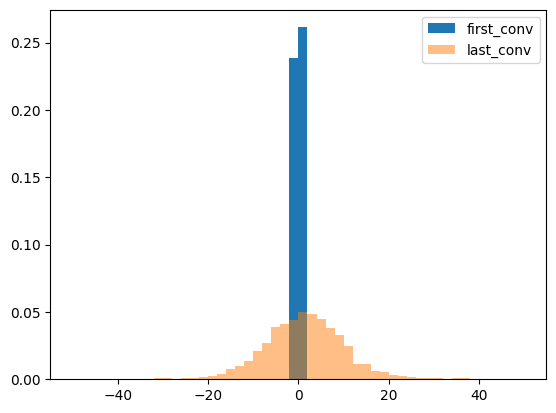

Finished Training


In [71]:
n_epochs = 1
for epoch in range(n_epochs):  # loop over the dataset multiple times

    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        # get the inputs; data is a list of [inputs, labels]
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)

        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = long_net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # print statistics
        running_loss += loss.item()

    print('[%d/%d] loss: %.3f' %
          (epoch+1 , n_epochs, running_loss / 2000))
    running_loss = 0.0
#     pd.DataFrame(long_net.conv1.weight.grad.cpu().detach().numpy().reshape(-1)).hist(bins=30)
    plt.hist(long_net.conv1.weight.grad.cpu().detach().numpy().reshape(-1),bins=50, label="first_conv",density=True,range=[-50,50])
    plt.hist(long_net.convs[9].weight.grad.cpu().detach().numpy().reshape(-1),bins=50, alpha=0.5, label="last_conv",density=True,range=[-50,50])
    plt.legend(loc='upper right')
    plt.show()
    plt.close()
    

print('Finished Training')

In [72]:
class LongNet(nn.Module):
    def __init__(self):
        super().__init__()
        ## Warstwa konwolucyjna
        self.n_convs =  10
        n_channels = 10
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=n_channels, kernel_size=5, stride=1, padding=0)
        self.conv2 = nn.Conv2d(in_channels=n_channels, out_channels=n_channels, kernel_size=5, stride=1, padding=0)
        self.convs = [nn.Conv2d(in_channels=n_channels*2, out_channels=n_channels, kernel_size=5, stride=1, padding=2) for _ in range(self.n_convs)]
        self.bns = [nn.BatchNorm2d(n_channels) for _ in range(self.n_convs)]
     
        ## Warstwa max pooling 
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.fc1 = nn.Linear(n_channels * 12 * 12, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        res = F.relu(self.conv2(x))
        x = res
        for i in range(self.n_convs):
            x = torch.cat([x,res],dim=1)
            x = F.relu(self.convs[i](x))
            x = self.bns[i](x)
        x = self.pool1(x)
        x = torch.flatten(x, 1) # flatten all dimensions except batch
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x


long_net = LongNet().to(device)
for conv in long_net.convs:
    conv.to(device)
for bn in long_net.bns:
    bn.to(device)
long_net

LongNet(
  (conv1): Conv2d(3, 10, kernel_size=(5, 5), stride=(1, 1))
  (conv2): Conv2d(10, 10, kernel_size=(5, 5), stride=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=1440, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)

In [ ]:
for epoch in range(n_epochs):  # loop over the dataset multiple times

    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        # get the inputs; data is a list of [inputs, labels]
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)

        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = long_net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # print statistics
        running_loss += loss.item()

    print('[%d/%d] loss: %.3f' %
          (epoch+1 , n_epochs, running_loss / 2000))
    running_loss = 0.0
    plt.hist(long_net.conv1.weight.grad.cpu().detach().numpy().reshape(-1),bins=50, label="first_conv",density=True,range=[-50,50])
    plt.hist(long_net.convs[9].weight.grad.cpu().detach().numpy().reshape(-1),bins=50, alpha=0.5, label="last_conv",density=True,range=[-50,50])
    plt.legend(loc='upper right')
    plt.show()
    plt.close()
    

print('Finished Training')

In [73]:
from torchviz import make_dot

In [74]:
make_dot(loss)

ExecutableNotFound: failed to execute PosixPath('dot'), make sure the Graphviz executables are on your systems' PATH

## Co tak naprawdę robią CNNy?

In [75]:
def plot_filters_multi_channel(t):
    num_kernels = t.shape[0]

    num_cols = 12
    num_rows = num_kernels

    fig = plt.figure(figsize=(num_cols, num_rows))

    # looping through all the kernels
    for i in range(t.shape[0]):
        ax1 = fig.add_subplot(num_rows, num_cols, i + 1)

        # for each kernel, we convert the tensor to numpy
        npimg = np.array(t[i].numpy(), np.float32)
        # standardize the numpy image
        npimg = (npimg - np.mean(npimg)) / np.std(npimg)
        npimg = np.minimum(1, np.maximum(0, (npimg + 0.5)))
        npimg = npimg.transpose((1, 2, 0))
        ax1.imshow(npimg)
        ax1.axis("off")
        ax1.set_title(str(i))
        ax1.set_xticklabels([])
        ax1.set_yticklabels([])

    plt.tight_layout()
    plt.show()


def plot_filters_single_channel(t, n_first_neurons=None, n_first_channels=None):

    # kernels depth * number of kernels
    n_neurons = t.shape[0]
    n_channels = t.shape[1]
    if n_first_neurons is not None:
        n_neurons = n_first_neurons
        t = t[:n_first_neurons, :, :, :]
    if n_first_channels is not None:
        n_channels = n_first_channels
        t = t[:, :n_first_channels, :, :]

    nplots = n_neurons * n_channels
    ncols = 12

    nrows = 1 + nplots // ncols
    # convert tensor to numpy image
    npimg = np.array(t.numpy(), np.float32)

    count = 0
    fig = plt.figure(figsize=(ncols, nrows))

    # looping through all the kernels in each channel
    for i in range(t.shape[0]):
        for j in range(t.shape[1]):
            count += 1
            ax1 = fig.add_subplot(nrows, ncols, count)
            npimg = np.array(t[i, j].numpy(), np.float32)
            npimg = (npimg - np.mean(npimg)) / np.std(npimg)
            npimg = np.minimum(1, np.maximum(0, (npimg + 0.5)))
            ax1.imshow(npimg)
            ax1.set_title(str(i) + "," + str(j))
            ax1.axis("off")
            ax1.set_xticklabels([])
            ax1.set_yticklabels([])

    plt.tight_layout()
    plt.show()


def plot_weights(model, layer_num, single_channel=False, n_first_neurons=None, n_first_channels=None):

    # extracting the model features at the particular layer number
    layer = model.features[layer_num]
    print(layer.__class__)

    # checking whether the layer is convolution layer or not
    if isinstance(layer, nn.Conv2d):
        # getting the weight tensor data
        weight_tensor = model.features[layer_num].weight.data

        if single_channel:
            plot_filters_single_channel(
                weight_tensor, n_first_neurons=n_first_neurons, n_first_channels=n_first_channels
            )

        else:
            if weight_tensor.shape[1] == 3:
                plot_filters_multi_channel(weight_tensor)
            else:
                plot_filters_multi_channel(weight_tensor[:, :3, :, :])
                print("Plot limited to first 3 channels only")

    else:
        print("Can only visualize layers which are convolutional")

In [76]:
alexnet = models.alexnet(weights="IMAGENET1K_V1")

Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /home/linux/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:15<00:00, 16.3MB/s] 


![](https://viso.ai/wp-content/uploads/2024/04/alexNet-architecture.png)

In [77]:
alexnet

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

**pytanie**: czym jest AdaptiveAvgPool2d?

In [78]:
m = nn.AdaptiveAvgPool2d((5, 7))
input = torch.randn(1, 64, 8, 9)
output = m(input)
print(f"inp: {input.shape} -> out: {output.shape}")

m = nn.AdaptiveAvgPool2d(7)
input = torch.randn(1, 64, 10, 9)
output = m(input)
print(f"inp: {input.shape} -> out: {output.shape}")

m = nn.AdaptiveAvgPool2d((None, 7))
input = torch.randn(1, 64, 10, 9)
output = m(input)
print(f"inp: {input.shape} -> out: {output.shape}")

inp: torch.Size([1, 64, 8, 9]) -> out: torch.Size([1, 64, 5, 7])
inp: torch.Size([1, 64, 10, 9]) -> out: torch.Size([1, 64, 7, 7])
inp: torch.Size([1, 64, 10, 9]) -> out: torch.Size([1, 64, 10, 7])


<class 'torch.nn.modules.conv.Conv2d'>


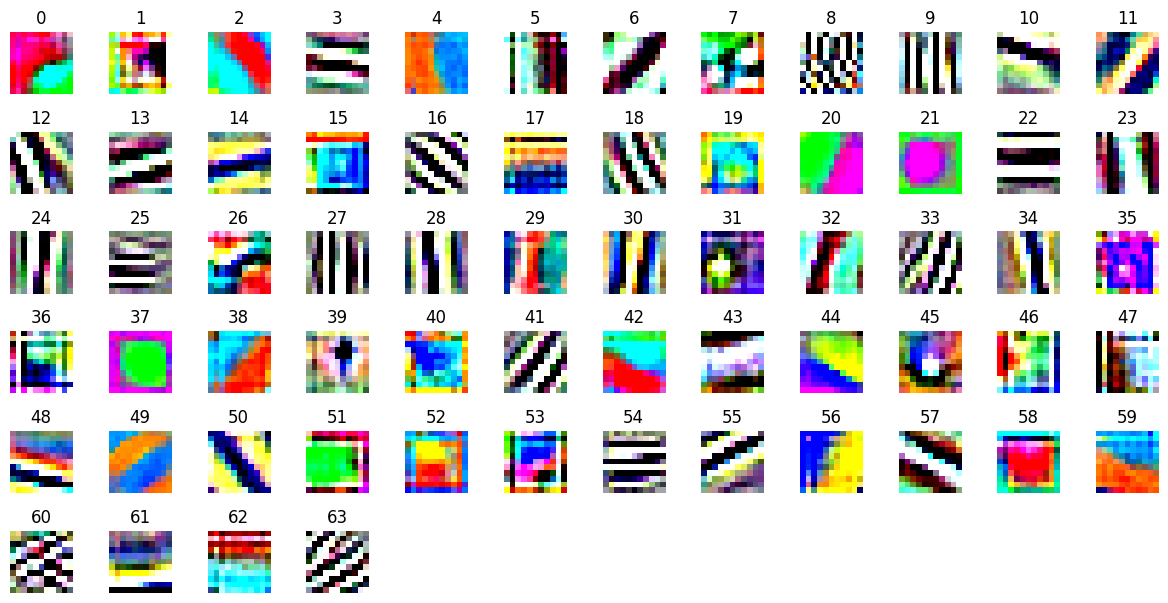

In [79]:
plot_weights(alexnet, 0, single_channel = False)

<class 'torch.nn.modules.conv.Conv2d'>


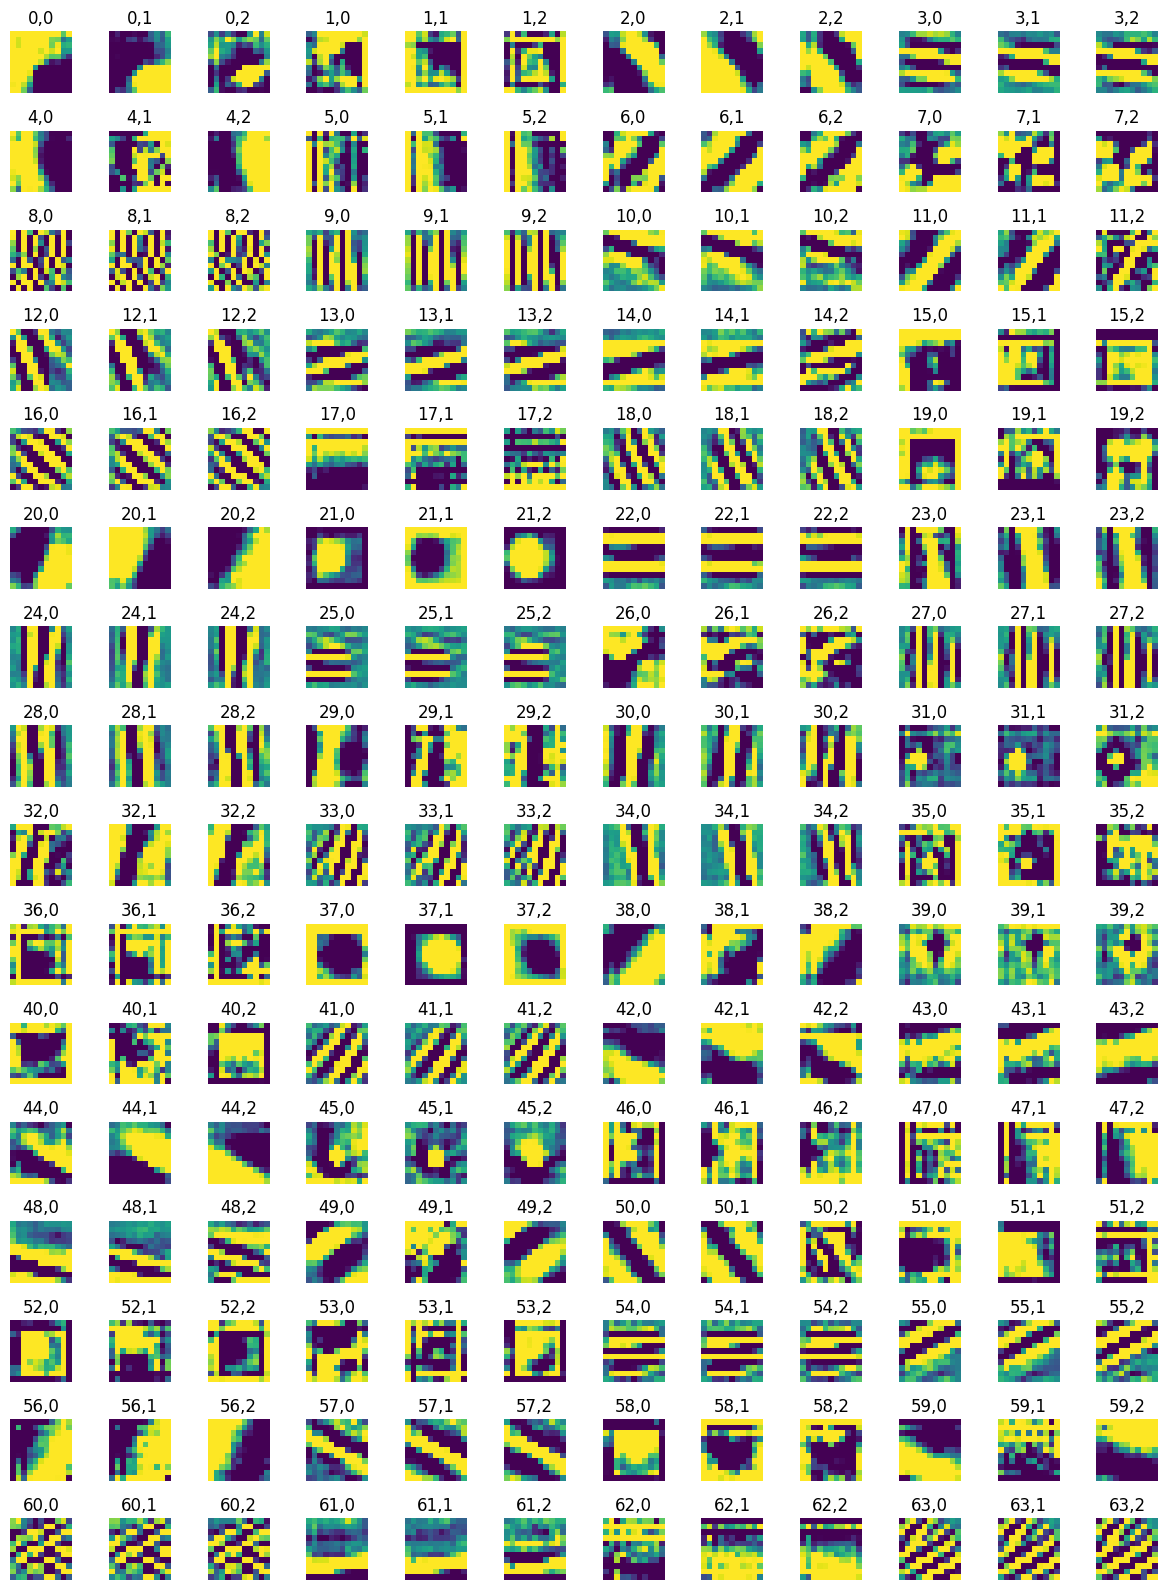

In [80]:
plot_weights(alexnet, 0, single_channel = True)

<class 'torch.nn.modules.conv.Conv2d'>


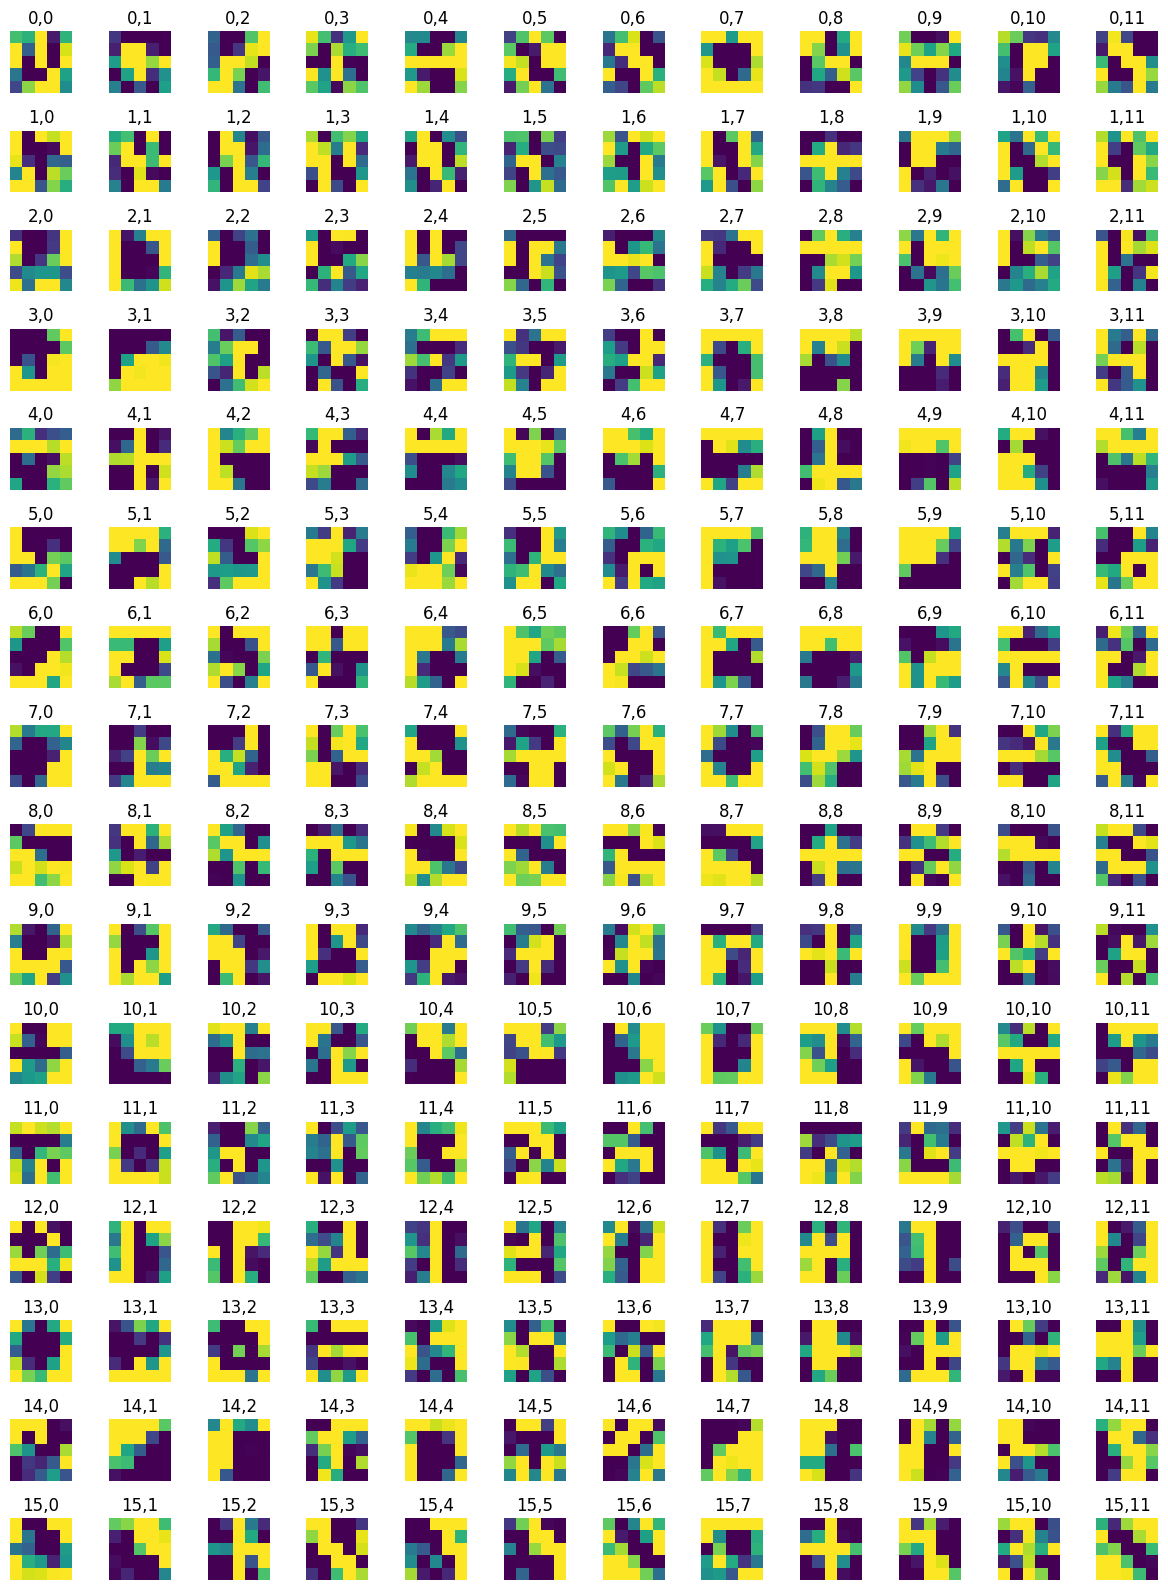

In [81]:
plot_weights(alexnet, 3, single_channel = True, n_first_neurons=16, n_first_channels=12)

## Zadanie
Znajdź błędy i napraw model tak żeby działał i uczył się na zbiorze fashionMNIST. Podpowiedź:

https://x.com/ylecun/status/1459943933027487744

In [82]:
import torch.optim as optim
import torch.nn as nn
import torch.nn.functional as F

In [ ]:
transform = transforms.Compose([transforms.ToTensor()])
batch_size = 32

trainset = torchvision.datasets.FashionMNIST(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                          shuffle=True)
testset = torchvision.datasets.FashionMNIST(root='./data', train=False,
                                       download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                         shuffle=False)

In [102]:
class FashionNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=6, kernel_size=5, stride=1, padding=0)
        self.bn1 = nn.BatchNorm2d(6)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.bn2 = nn.BatchNorm2d(16)
        self.pool2 = nn.MaxPool2d(2)
        self.fc1 = nn.Linear(16 * 4 * 4, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.bn1(x)
        x = self.pool2(F.relu(self.conv2(x)))
        x = self.bn2(x)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [103]:
set_seed(42)
net = FashionNet().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(), lr=0.001)

In [104]:
for epoch in range(1):  # loop over the dataset multiple times
    running_loss = 0.0
    for data in trainloader:
        # get the inputs; data is a list of [inputs, labels]
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)

        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # print statistics
        running_loss += loss.item()

    print(f"{epoch+1}/5, loss: {running_loss / 2000:.3f}")

print('Finished Training')

1/5, loss: 0.398
Finished Training


In [105]:
correct = 0
total = 0
with torch.no_grad():
    for data in testloader:
        images, labels = data
        images = images.to(device)
        # calculate outputs by running images through the network 
        outputs = net(images).cpu()
        # the class with the highest energy is what we choose as prediction
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Accuracy: {100 * correct / total}%")

Accuracy: 87.21%


## Pre-trained models and Transfer Learning

![](https://framerusercontent.com/images/n6FZeNKpxNGHvLDBnWU1aHvs.jpeg?width=2672&height=1825)

In [106]:
import torchvision
from torchvision.models import ResNet18_Weights
from torch import optim

In [107]:
def init_resnet():
    resnet = torchvision.models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
    for param in resnet.parameters():
        param.requires_grad = False
    return resnet

net = init_resnet()

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /home/linux/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:01<00:00, 23.6MB/s]


In [108]:
net

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [109]:
batch_size = 32

transform = transforms.Compose(
    [transforms.RandomHorizontalFlip(0.5),
     transforms.RandomRotation(24),
     transforms.ToTensor(),
     transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False,download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,shuffle=True, num_workers=16)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,shuffle=False, num_workers=16)

N_CLASSES = len(trainset.classes)

In [110]:
def train_net(net, trainloader, testloader, criterion, optimizer, n_epochs=15):
    for epoch in range(n_epochs):
        net.train()
        running_loss = 0.0
        for i, data in enumerate(trainloader, 0):
            # get the inputs; data is a list of [inputs, labels]
            inputs, labels = data
            inputs, labels = inputs.to(device), labels.to(device)

            # zero the parameter gradients
            optimizer.zero_grad()

            # forward + backward + optimize
            outputs = net(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            # print statistics
            running_loss += loss.item()

        correct = 0
        total = 0
        net.eval()
        with torch.no_grad():
            for data in testloader:
                images, labels = data
                images = images.to(device)
                # calculate outputs by running images through the network 
                outputs = net(images).cpu()
                # the class with the highest energy is what we choose as prediction
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        print(f"[{epoch+1}/{n_epochs}] loss: {running_loss/2000:.3f} / acc: {100*correct/total:.1f}%")

    print('Finished Training')

In [111]:
def init_resnet_with_fc(n_classes=N_CLASSES, freeze_pretrained=True):
    resnet = torchvision.models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
    for param in resnet.parameters():
        param.requires_grad = not freeze_pretrained
    resnet.fc = nn.Linear(resnet.fc.in_features, n_classes) # requires_grad by default!
    return resnet

+ trenowanie ostatniej warstwy:

In [114]:
set_seed(42)
net = init_resnet_with_fc(N_CLASSES, freeze_pretrained=True)

criterion = nn.CrossEntropyLoss()
net = net.to(device)
optimizer = optim.Adam(net.parameters(), lr=1e-3)
train_net(net, trainloader, testloader, criterion, optimizer, n_epochs=1)

KeyboardInterrupt: 

+ trenowanie wszystkich warstw:

In [ ]:
set_seed(42)
net = init_resnet_with_fc(N_CLASSES, freeze_pretrained=False)

criterion = nn.CrossEntropyLoss()
net = net.to(device)
optimizer = optim.Adam(net.parameters(), lr=3e-4)
train_net(net, trainloader, testloader, criterion, optimizer, n_epochs=1)

In [ ]:
set_seed(42)
net = init_resnet_with_fc(N_CLASSES, freeze_pretrained=False)

criterion = nn.CrossEntropyLoss()
net = net.to(device)

base_params = [p for name, p in net.named_parameters() if "fc" not in name]
optimizer = optim.Adam([
    {"params": base_params,          "lr": 3e-4},  # pretrained layers
    {"params": net.fc.parameters(),  "lr1": 1e-3},  # fresh head
])
train_net(net, trainloader, testloader, criterion, optimizer, n_epochs=1)